# 1. Environment Setup and Dependencies

In this section, we initialize the analysis environment by importing essential libraries categorized by their functionality:


In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
import lightgbm as lgb

from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print(" All libraries imported successfully")

 All libraries imported successfully


# 2. Loading all datasets

here,loaded the raw datasets into Pandas DataFrames. The data comes from two primary sources: **CinePOS** and **BookNow** .

**About Datasets**
* **Theater Data:** Locations and details for both systems (`cinepos_theaters`, `booknow_theaters`).
* **Booking Data:** Transactional data containing ticket sales (`cinepos_booking`, `booknow_booking`).
* **Linkage Data:** `movie_theater_id_relation` allows us to map theaters between the two different systems.
* **Target Variable:** `booknow_visits` acts as our ground truth for the number of visits we are trying to predict.
* **External Factors:** `date_info` provides calendar context (holidays, weekends).



In [2]:


# Define base path for datasets
# For Kaggle: use '/kaggle/input/your-competition-name/'
# For local: use '' (empty string)
import os

# Automatically detect environment
if os.path.exists('/kaggle/input'):
    # Kaggle environment - files are in subdirectories
    BASE_PATH = '/kaggle/input/Cinema_Audience_Forecasting_challenge/'
else:
    # Local environment - files are in the same directory
    BASE_PATH = ''

# Load all datasets
print("Loading datasets...")
print(f"Using base path: {BASE_PATH}")

# Kaggle structure: /kaggle/input/Cinema_Audience_Forecasting_challenge/<dataset_name>/<file_name>.csv
# Local structure: ./<file_name>.csv
if BASE_PATH:
    cinepos_theaters = pd.read_csv(f'{BASE_PATH}cinePOS_theaters/cinePOS_theaters.csv')
    booknow_theaters = pd.read_csv(f'{BASE_PATH}booknow_theaters/booknow_theaters.csv')
    theater_mapping = pd.read_csv(f'{BASE_PATH}movie_theater_id_relation/movie_theater_id_relation.csv')
    cinepos_booking = pd.read_csv(f'{BASE_PATH}cinePOS_booking/cinePOS_booking.csv')
    booknow_booking = pd.read_csv(f'{BASE_PATH}booknow_booking/booknow_booking.csv')
    booknow_visits = pd.read_csv(f'{BASE_PATH}booknow_visits/booknow_visits.csv')
    date_info = pd.read_csv(f'{BASE_PATH}date_info/date_info.csv')
    sample_submission = pd.read_csv(f'{BASE_PATH}sample_submission/sample_submission.csv')
else:
    cinepos_theaters = pd.read_csv('cinePOS_theaters.csv')
    booknow_theaters = pd.read_csv('booknow_theaters.csv')
    theater_mapping = pd.read_csv('movie_theater_id_relation.csv')
    cinepos_booking = pd.read_csv('cinePOS_booking.csv')
    booknow_booking = pd.read_csv('booknow_booking.csv')
    booknow_visits = pd.read_csv('booknow_visits.csv')
    date_info = pd.read_csv('date_info.csv')
    sample_submission = pd.read_csv('sample_submission.csv')

# Display dataset information
print("\n Datasets loaded successfully:\n")
datasets_info = {
    'CinePOS Theaters': cinepos_theaters.shape,
    'BookNow Theaters': booknow_theaters.shape,
    'Theater Mapping': theater_mapping.shape,
    'CinePOS Bookings': cinepos_booking.shape,
    'BookNow Bookings': booknow_booking.shape,
    'BookNow Visits (Target)': booknow_visits.shape,
    'Date Information': date_info.shape,
    'Sample Submission': sample_submission.shape
}

for name, shape in datasets_info.items():
    print(f"  {name:25s} {shape}")

Loading datasets...
Using base path: /kaggle/input/Cinema_Audience_Forecasting_challenge/

 Datasets loaded successfully:

  CinePOS Theaters          (4690, 5)
  BookNow Theaters          (829, 5)
  Theater Mapping           (150, 2)
  CinePOS Bookings          (1641966, 4)
  BookNow Bookings          (68336, 4)
  BookNow Visits (Target)   (214046, 3)
  Date Information          (547, 2)
  Sample Submission         (38062, 2)


## 3. Initial Data Exploration

In [3]:
# Convert datetime columns for proper analysis
print("Converting datetime columns...")

booknow_visits['show_date'] = pd.to_datetime(booknow_visits['show_date'])
date_info['show_date'] = pd.to_datetime(date_info['show_date'])
cinepos_booking['show_datetime'] = pd.to_datetime(cinepos_booking['show_datetime'])
cinepos_booking['booking_datetime'] = pd.to_datetime(cinepos_booking['booking_datetime'])
booknow_booking['show_datetime'] = pd.to_datetime(booknow_booking['show_datetime'])
booknow_booking['booking_datetime'] = pd.to_datetime(booknow_booking['booking_datetime'])

print(" Datetime conversions complete")

Converting datetime columns...
 Datetime conversions complete


In [4]:
# Examine target variable distribution
print("Target Variable: audience_count")
print("="*50)
print(booknow_visits['audience_count'].describe())
print(f"\nMissing values: {booknow_visits['audience_count'].isna().sum()}")

Target Variable: audience_count
count    214046.000000
mean         41.616568
std          32.834918
min           2.000000
25%          18.000000
50%          34.000000
75%          58.000000
max        1350.000000
Name: audience_count, dtype: float64

Missing values: 0




Before merging datasets or training models, we must perform a check on the data to identify gaps. Missing data can lead to runtime errors or biased predictions.



In [5]:
# Check for missing data across datasets
print("Missing Data Analysis:")
print("="*50)

missing_data = {
    'CinePOS Theaters (latitude)': cinepos_theaters['latitude'].isna().sum(),
    'CinePOS Theaters (longitude)': cinepos_theaters['longitude'].isna().sum(),
    'BookNow Theaters': booknow_theaters.isna().sum().sum(),
    'BookNow Visits': booknow_visits.isna().sum().sum()
}

for name, count in missing_data.items():
    status = "done" if count == 0 else f" {count} missing"
    print(f"  {name:30s} {status}")

Missing Data Analysis:
  CinePOS Theaters (latitude)     3861 missing
  CinePOS Theaters (longitude)    3861 missing
  BookNow Theaters                515 missing
  BookNow Visits                 done


##  4: Exploratory Data Analysis (EDA)

In this section, we perform comprehensive visual analysis to understand:
- Target variable distribution and patterns
- Temporal trends and seasonality
- Theater characteristics and their impact
- Missing data patterns
- Feature correlations and relationships



Visualizing Target Variable Distribution

In this section, we use `Matplotlib` to visualize the distribution of `audience_count` (our target variable) using two complementary plots:
1.  **Histogram (Left):** To visualize the frequency distribution and shape of the data.
2.  **Box Plot (Right):** To explicitly detect outliers and visualize the Interquartile Range (IQR).




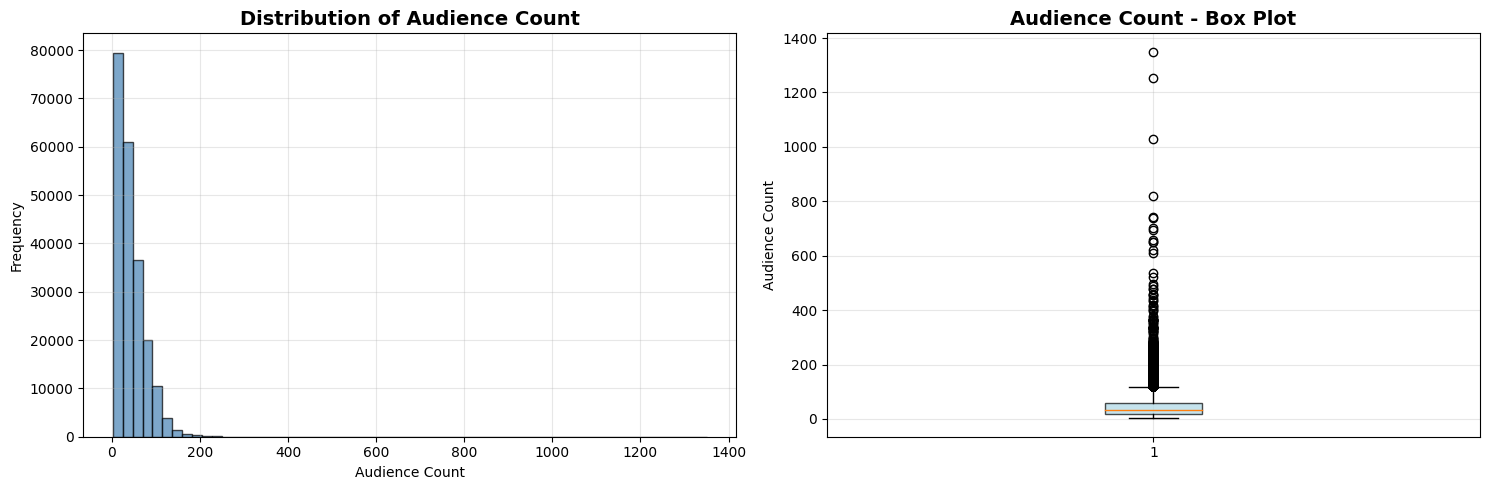

In [6]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.hist(booknow_visits['audience_count'], bins=60, edgecolor='black', color='steelblue', alpha=0.7)
plt.title('Distribution of Audience Count', fontsize=14, fontweight='bold')
plt.xlabel('Audience Count')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot(booknow_visits['audience_count'], vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue', alpha=0.7))
plt.title('Audience Count - Box Plot', fontsize=14, fontweight='bold')
plt.ylabel('Audience Count')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Insights

* **Right-Skewed Distribution:** The histogram clearly shows a **positive skew (right-skewed)**. The vast majority of screenings have low audience counts (clustering between 0-100), while the tail extends far to the right.
* **Significant Outliers:** The Box Plot confirms the presence of massive outliers (the circles above the top whisker). These likely represent "Blockbuster" movies or peak weekend shows where attendance spikes significantly compared to the average.

### 2.  Impact of Day of Week 

 the relationship between the **Day of the Week** and the **Audience Count** to understand weekly patterns.

**Process:**
1.  **Data Enrichment:** We merge the `booknow_visits` table with `date_info` to append the `day_of_week` feature.
2.  **Aggregation:** We calculate the Mean, Median, and Standard Deviation for each day to summarize central tendencies.
3.  **Visualization:** We plot the average attendance and the spread of data to identify peak operational days.



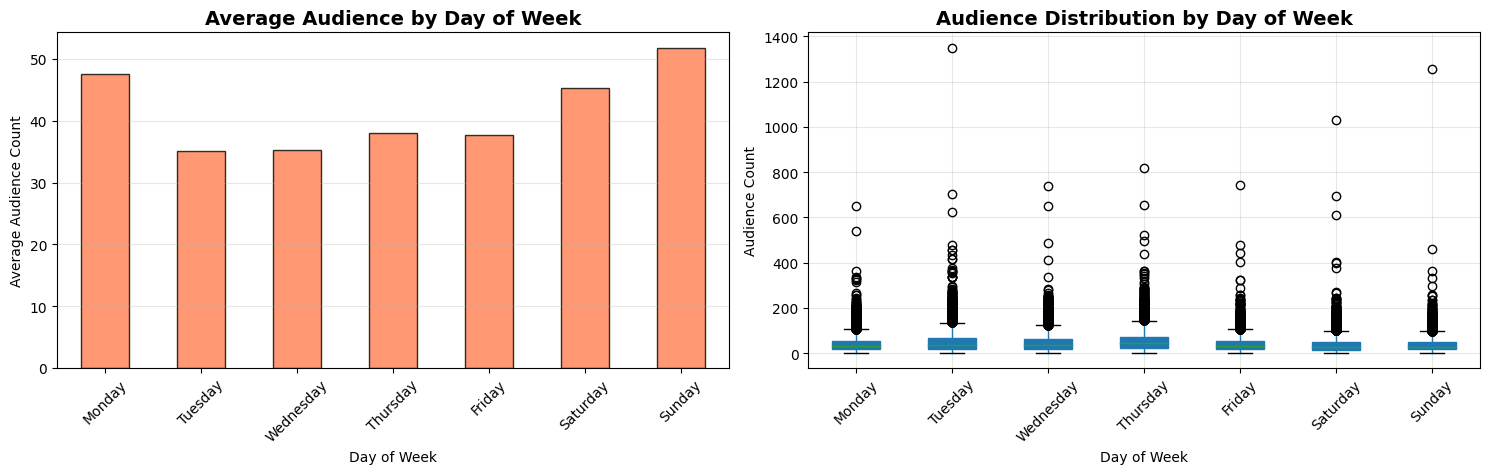

In [7]:
visits_with_dow = booknow_visits.merge(date_info[['show_date', 'day_of_week']], on='show_date', how='left')
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_stats = visits_with_dow.groupby('day_of_week')['audience_count'].agg(['mean', 'median', 'std']).reindex(day_order)

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
dow_stats['mean'].plot(kind='bar', color='coral', edgecolor='black', alpha=0.8)
plt.title('Average Audience by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Average Audience Count')
plt.xticks(rotation=45)
plt.grid(alpha=0.3, axis='y')

plt.subplot(1, 2, 2)
visits_with_dow.boxplot(column='audience_count', by='day_of_week', ax=plt.gca(), 
                         patch_artist=True, figsize=(15, 5))
plt.title('Audience Distribution by Day of Week', fontsize=14, fontweight='bold')
plt.suptitle('')
plt.xlabel('Day of Week')
plt.ylabel('Audience Count')
plt.xticks(range(1, 8), day_order, rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

###  Insights 
* **The Weekend Surge:** As expected, **Sunday** records the highest average attendance (peaks above 50), confirming strong weekly seasonality.
* **The "Monday" :** Surprisingly, **Monday** shows very strong attendance, rivaling Saturday. This could indicate a specific market behavior (e.g., "Cheap Ticket Mondays" or holiday effects included in the dataset) that the model must learn.
* **Mid-Week :** Tuesday and Wednesday show the lowest average attendance.
* **on Tuesdays:** Looking at the Box Plot (Right), while Tuesday has a low average, it possesses extreme **outliers** (some of the highest individual screenings). This suggests that while average days are slow, massive blockbusters or premieres might occur on Tuesdays

### 3.  Monthly Trends

Moving beyond weekly seasonality, we analyze the data at a **Monthly level** to identify long-term trends and potential anomalies. We aggregate the data in two ways:
1.  **Average Audience (Line Plot):** Measures the *efficiency* or popularity of individual screenings per month.
2.  **Total Audience (Bar Plot):** Measures the *scale* or total volume of visitors per month.



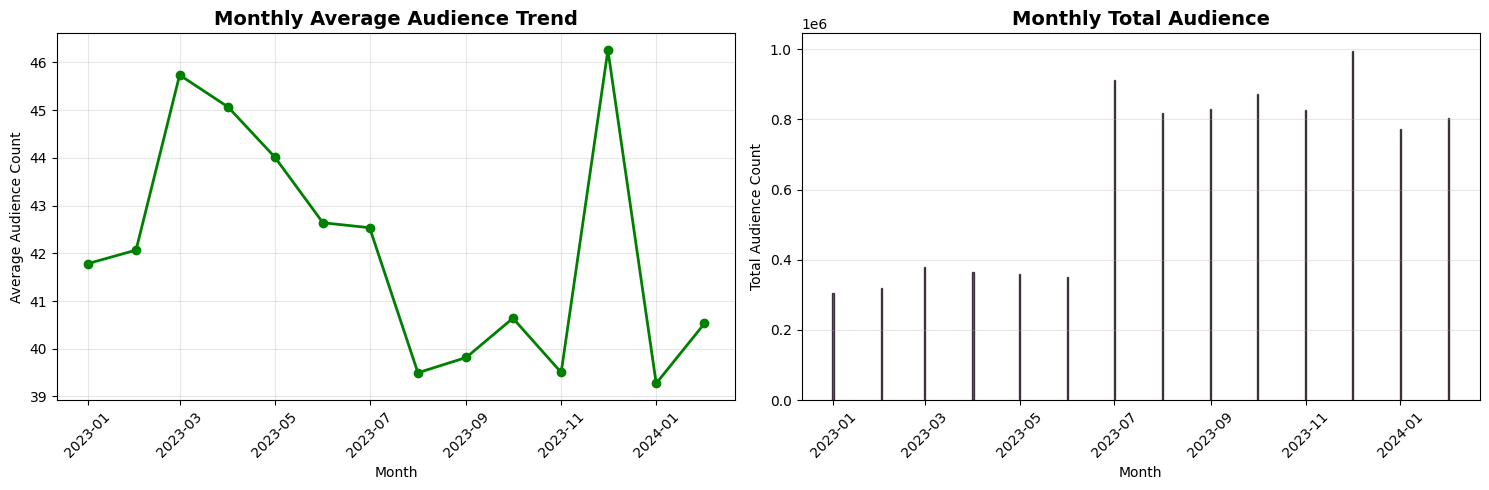

In [8]:
monthly_avg = booknow_visits.groupby(booknow_visits['show_date'].dt.to_period('M'))['audience_count'].mean()
monthly_avg.index = monthly_avg.index.to_timestamp()

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(monthly_avg, marker='o', linestyle='-', color='green', linewidth=2, markersize=6)
plt.title('Monthly Average Audience Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Audience Count')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
monthly_total = booknow_visits.groupby(booknow_visits['show_date'].dt.to_period('M'))['audience_count'].sum()
monthly_total.index = monthly_total.index.to_timestamp()
plt.bar(monthly_total.index, monthly_total.values, color='purple', alpha=0.7, edgecolor='black')
plt.title('Monthly Total Audience', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Audience Count')
plt.xticks(rotation=45)
plt.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

**Insights:**
* **The "Blockbuster" Spike (Nov 2023):** The Line Plot (Left) shows a massive spike in **Average Audience** in late 2023 (peaking in November). This indicates a period where almost every show was full—likely due to a specific holiday release or blockbuster movie event.
* **Volume Shift (July 2023):** The Bar Plot (Right) reveals a structural break in the data. Before July 2023, the *Total* audience was relatively low. From July onwards, the total volume nearly doubled and stayed high. This suggests the theater chain either opened new screens, increased the number of daily shows, or acquired a competitor around mid-year.
* **Inverse Relationship:** Interestingly, in months like July-August, the *Total* audience is high, but the *Average* (green line) actually dips. This implies that while more people came, the theater also ran many more screenings, slightly diluting the crowd per show.

### 4. Theater Type Analysis

Here, we identify whether the *genre* or *type* of the theater influences attendance. This requires merging the static theater metadata (`booknow_theaters`) with the transactional visit data (`booknow_visits`).

**Visualizations:**
1.  **Pie Chart:** Displays the inventory mix (How many theaters of each type do we have?).
2.  **Bar Chart:** Displays the performance efficiency (What is the average attendance per type?).



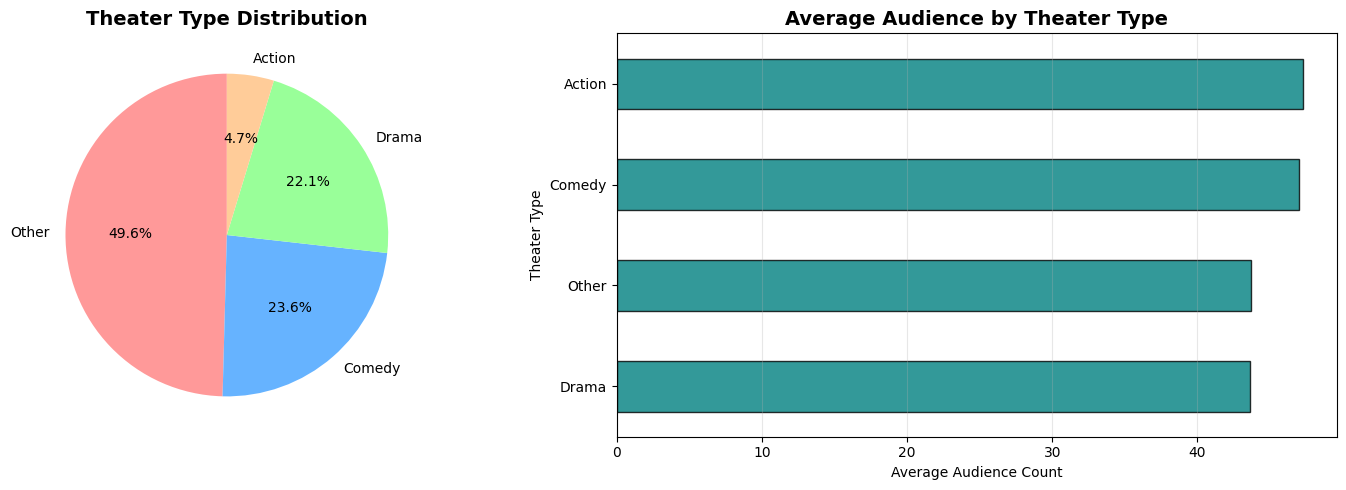

In [9]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
theater_type_counts = booknow_theaters['theater_type'].value_counts()
plt.pie(theater_type_counts, labels=theater_type_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'])
plt.title('Theater Type Distribution', fontsize=14, fontweight='bold')

plt.subplot(1, 2, 2)
visits_theater_merge = booknow_visits.merge(booknow_theaters[['book_theater_id', 'theater_type']], 
                                             on='book_theater_id', how='left')
theater_avg = visits_theater_merge.groupby('theater_type')['audience_count'].mean().sort_values()
theater_avg.plot(kind='barh', color='teal', edgecolor='black', alpha=0.8)
plt.title('Average Audience by Theater Type', fontsize=14, fontweight='bold')
plt.xlabel('Average Audience Count')
plt.ylabel('Theater Type')
plt.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

**Insights:**
* **The "Other" Dominance:** Nearly 50% of the theaters are categorized as "Other". This suggests that half of our facilities are either multi-purpose screens or lack specific genre metadata.
* **The "Action" Paradox (Quality vs. Quantity):**
    * **Scarcity:** "Action" theaters are the rarest category, making up only **4.7%** of the total inventory (Pie Chart).
    * **Popularity:** However, they have the **highest average attendance** (Bar Chart).
    * **Conclusion:** This indicates a high demand for Action movies/screens that is potentially undersupplied.
* **Consistency:** Comedy and Action are the top performers, while Drama and "Other" lag slightly behind. However, the variance between the highest (Action) and lowest (Drama) is not massive, implying that while type matters, it is not the *only* factor driving attendance.

### 5. Theater Area Distribution

### 5. Theatre Area Distribution

Location is often the primary driver of retail success. In this section, we analyze the performance of different theater "Areas" (clusters of theaters) to understand the relationship between theater density and crowd size.

**Analysis Approach:**
1.  **Supply (Left Chart):** We count the number of theaters per area to identify the largest market hubs.
2.  **Demand/Efficiency (Right Chart):** We calculate the average audience per screening to identify the most popular or efficient locations.



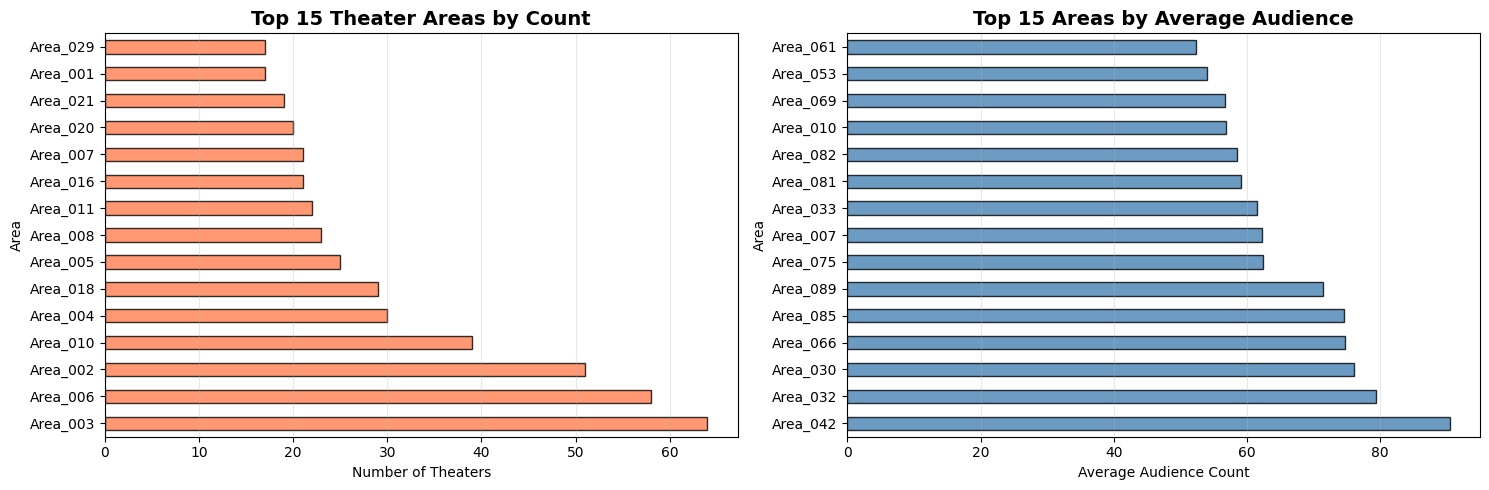

In [10]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
area_counts = booknow_theaters['theater_area'].value_counts().head(15)
area_counts.plot(kind='barh', color='coral', edgecolor='black', alpha=0.8)
plt.title('Top 15 Theater Areas by Count', fontsize=14, fontweight='bold')
plt.xlabel('Number of Theaters')
plt.ylabel('Area')
plt.grid(alpha=0.3, axis='x')

plt.subplot(1, 2, 2)
visits_area_merge = booknow_visits.merge(booknow_theaters[['book_theater_id', 'theater_area']], 
                                          on='book_theater_id', how='left')
area_audience = visits_area_merge.groupby('theater_area')['audience_count'].mean().sort_values(ascending=False).head(15)
area_audience.plot(kind='barh', color='steelblue', edgecolor='black', alpha=0.8)
plt.title('Top 15 Areas by Average Audience', fontsize=14, fontweight='bold')
plt.xlabel('Average Audience Count')
plt.ylabel('Area')
plt.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

**Insights:**

* **The "Hub" Locations:** `Area_003`, `Area_006`, and `Area_002` are the giants, containing the highest number of theaters. These likely represent major city centers or dense entertainment districts.
* **The "Hidden Gem" (Area_042):** Interestingly, the top-performing area by *attendance* (`Area_042`) does not appear in the top 3 by *count*. This suggests `Area_042` is a high-demand location that is not over-saturated—a perfect candidate for business expansion.
* **Supply-Demand Mismatch:** The list of areas with the *most* theaters is completely different from the list of areas with the *fullest* theaters. This indicates that the largest hubs might be suffering from "cannibalization" (too many theaters competing for the same crowd), while smaller areas are maximizing their capacity.

### 6. Top and Bottom Performing Theaters

### 6. Top & Bottom Perfoming Theaters

While "Area" analysis gives us a high-level view, we must also look at individual theater performance to identify specific outliers. Here, we rank unique `book_theater_id`s based on their average audience count to separate the "Star Performers" from the "Strugglers."

**Visualizations:**
1.  **Top 15 (Green):** The theaters with the highest average attendance (Efficiency).
2.  **Bottom 15 (Red):** The theaters with the lowest average attendance.



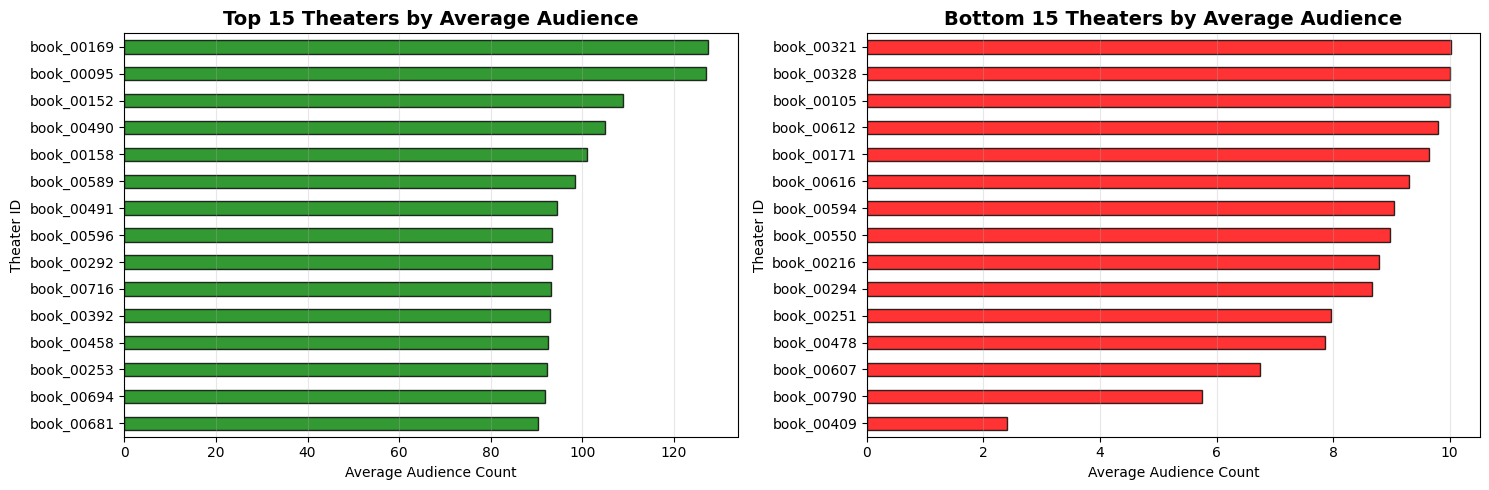

In [11]:
plt.figure(figsize=(15, 5))

theater_avg = booknow_visits.groupby('book_theater_id')['audience_count'].mean().sort_values()

plt.subplot(1, 2, 1)
theater_avg.tail(15).plot(kind='barh', color='green', edgecolor='black', alpha=0.8)
plt.title('Top 15 Theaters by Average Audience', fontsize=14, fontweight='bold')
plt.xlabel('Average Audience Count')
plt.ylabel('Theater ID')
plt.grid(alpha=0.3, axis='x')

plt.subplot(1, 2, 2)
theater_avg.head(15).plot(kind='barh', color='red', edgecolor='black', alpha=0.8)
plt.title('Bottom 15 Theaters by Average Audience', fontsize=14, fontweight='bold')
plt.xlabel('Average Audience Count')
plt.ylabel('Theater ID')
plt.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

**Insights:**
* **Massive Performance Gap:** There is a stark contrast between the top and bottom tiers. The best theaters average **~125 visitors per show**, while the worst average **< 3 visitors**. This represents a **60x difference** in performance.
* **Potential Data Anomalies (The "Bottom" List):** Theaters like `book_00409` average only ~2.5 people per show. This is suspiciously low.
    * *Business Hypothesis:* These might be theaters that are under renovation, effectively closed, or located in extremely remote areas.
    * *Data Hypothesis:* These could be "test" IDs used by the system administrators that should potentially be cleaned from the training data.
* **The "Power Players":** The top two theaters (`book_00169` and `book_00095`) significantly outperform the rest of the top 15, suggesting they are the flagship locations of the chain (likely IMAX or large capacity halls).

### 7. Audience Count Distribution and Outliers

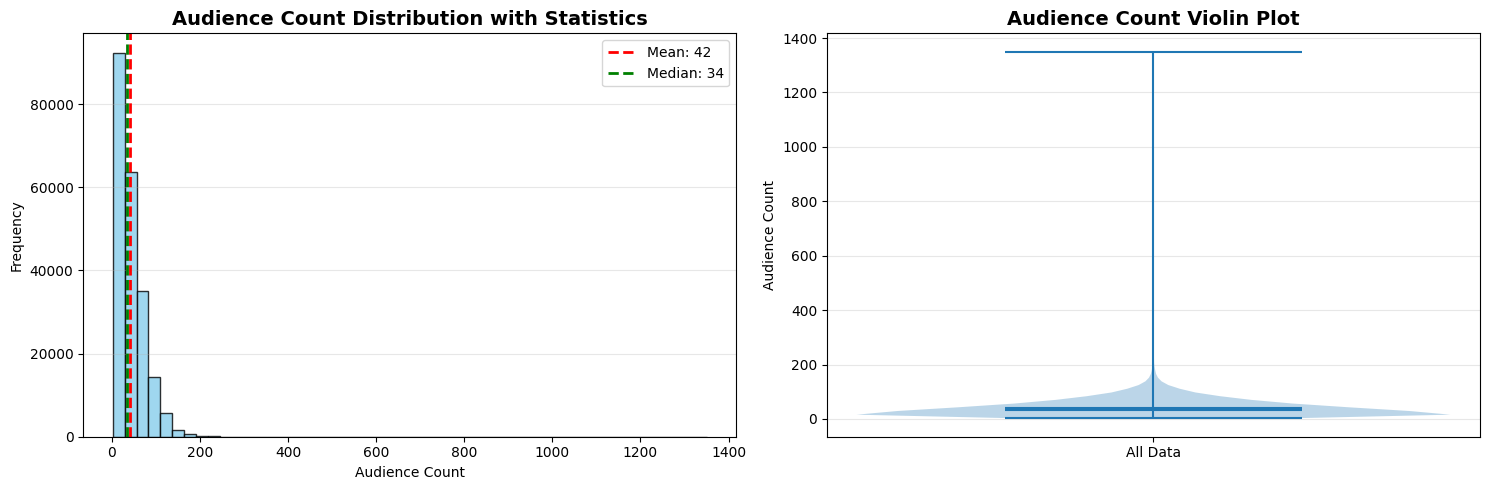

In [12]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.hist(visits_with_dow['audience_count'], bins=50, color='skyblue', edgecolor='black', alpha=0.8)
plt.axvline(visits_with_dow['audience_count'].mean(), color='red', linestyle='--', 
            linewidth=2, label=f"Mean: {visits_with_dow['audience_count'].mean():.0f}")
plt.axvline(visits_with_dow['audience_count'].median(), color='green', linestyle='--', 
            linewidth=2, label=f"Median: {visits_with_dow['audience_count'].median():.0f}")
plt.title('Audience Count Distribution with Statistics', fontsize=14, fontweight='bold')
plt.xlabel('Audience Count')
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.3, axis='y')

plt.subplot(1, 2, 2)
plt.violinplot([visits_with_dow['audience_count']], positions=[0], showmeans=True, showmedians=True)
plt.title('Audience Count Violin Plot', fontsize=14, fontweight='bold')
plt.ylabel('Audience Count')
plt.xticks([0], ['All Data'])
plt.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

**Insights:**
- Distribution shows right-skewed pattern with most values concentrated at lower audience counts
- Presence of outliers at the upper end indicates special high-attendance events
- Median is lower than mean, confirming positive skewness
- Violin plot reveals the density distribution and potential multimodal patterns

### 8. Temporal Patterns - Monthly and Quarter Analysis

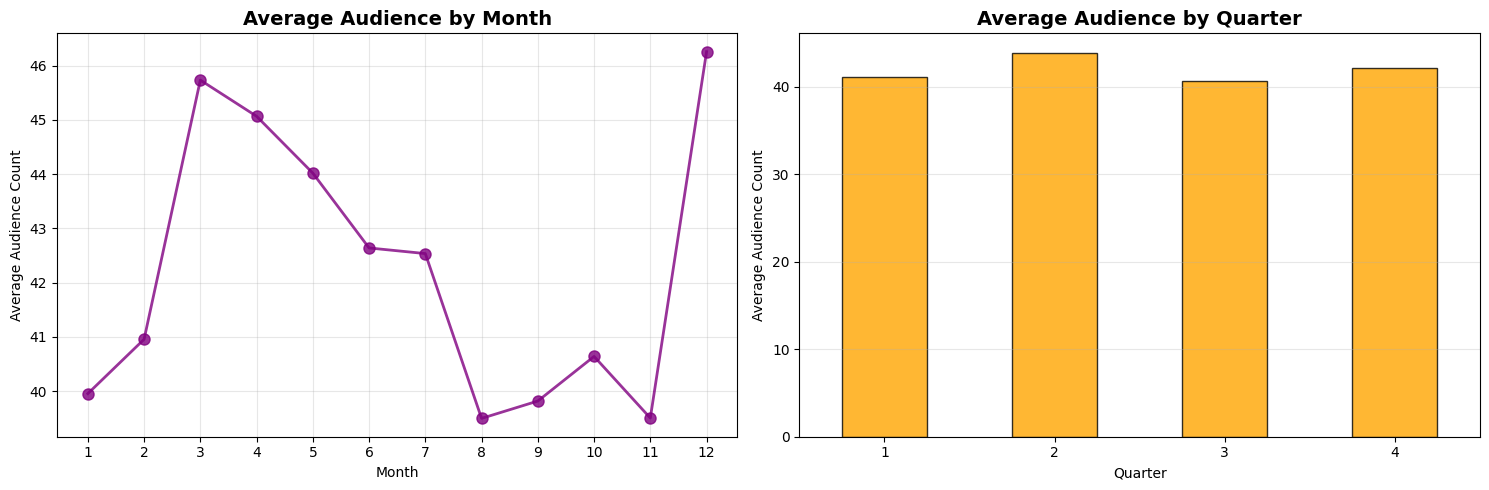

In [13]:
plt.figure(figsize=(15, 5))

booknow_visits['show_date'] = pd.to_datetime(booknow_visits['show_date'])
booknow_visits['month'] = booknow_visits['show_date'].dt.month
booknow_visits['quarter'] = booknow_visits['show_date'].dt.quarter

plt.subplot(1, 2, 1)
monthly_avg = booknow_visits.groupby('month')['audience_count'].mean()
plt.plot(monthly_avg.index, monthly_avg.values, marker='o', linewidth=2, 
         markersize=8, color='purple', alpha=0.8)
plt.title('Average Audience by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Audience Count')
plt.grid(alpha=0.3)
plt.xticks(range(1, 13))

plt.subplot(1, 2, 2)
quarterly_avg = booknow_visits.groupby('quarter')['audience_count'].mean()
quarterly_avg.plot(kind='bar', color='orange', edgecolor='black', alpha=0.8)
plt.title('Average Audience by Quarter', fontsize=14, fontweight='bold')
plt.xlabel('Quarter')
plt.ylabel('Average Audience Count')
plt.xticks(rotation=0)
plt.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

**Insights:**
- Clear monthly patterns reveal seasonal variations in cinema attendance
- Certain months show consistently higher audience counts indicating peak seasons
- Quarterly variations indicate seasonal demand fluctuations throughout the year
- Time-based features are essential predictors for accurate forecasting

### 9. Feature Correlation Analysis

### 9. Feature Correlation Analysis

here examining the statistical relationships between our numerical features and the target variable. 

**Visualizations:**
1.  **Heatmap (Left):** Shows the correlation between all numerical pairs. Red indicates a strong positive relationship ($r \approx 1$), while Blue indicates a strong negative relationship ($r \approx -1$).
2.  **Bar Chart (Right):** Focuses exclusively on how each feature correlates with `audience_count` (the target).



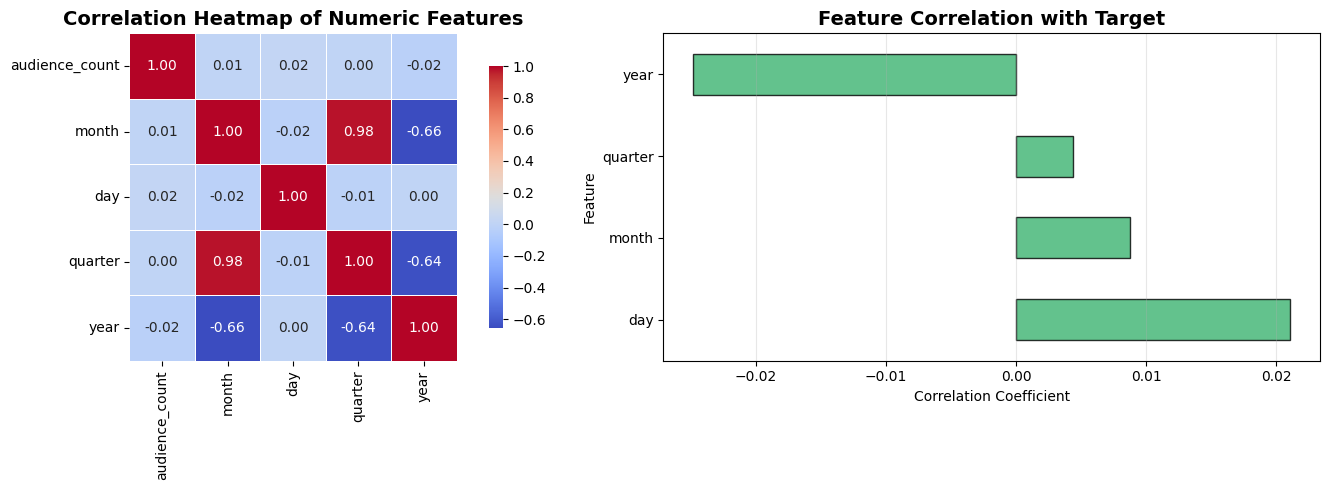

In [14]:
plt.figure(figsize=(15, 5))

booknow_visits_temp = booknow_visits.copy()
booknow_visits_temp['day'] = booknow_visits_temp['show_date'].dt.day
booknow_visits_temp['year'] = booknow_visits_temp['show_date'].dt.year

numeric_cols = ['audience_count', 'month', 'day', 'quarter', 'year']
correlation_matrix = booknow_visits_temp[numeric_cols].corr()

plt.subplot(1, 2, 1)
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Numeric Features', fontsize=14, fontweight='bold')

plt.subplot(1, 2, 2)
target_corr = correlation_matrix['audience_count'].sort_values(ascending=False)[1:]
target_corr.plot(kind='barh', color='mediumseagreen', edgecolor='black', alpha=0.8)
plt.title('Feature Correlation with Target', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Feature')
plt.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

**Insights:**

* **Weak Linear Correlation with Target:** The most striking observation is that `audience_count` has effectively **zero linear correlation** with `month`, `day`, or `year` (coefficients are between -0.02 and +0.02).
    * *Implication:* This means a simple Linear Regression model will fail. The relationship between time and cinema visits is **non-linear** (e.g., spikes in holidays, drops in mid-weeks) and cannot be captured by a straight line.
* **Multicollinearity Detected:** We observe a near-perfect correlation (0.98) between `month` and `quarter`. This makes sense (Q1 always contains Jan, Feb, Mar), but in linear models, this redundancy (Multicollinearity) can distort coefficient interpretation. We may need to drop one of these to reduce noise.
* **The "Year" Negative Trend:** The `year` feature has a slight negative correlation with the target. This aligns with our earlier finding where average attendance per show dipped slightly in 2024 compared to the 2023 peaks.

### 10. Year-over-Year Trends

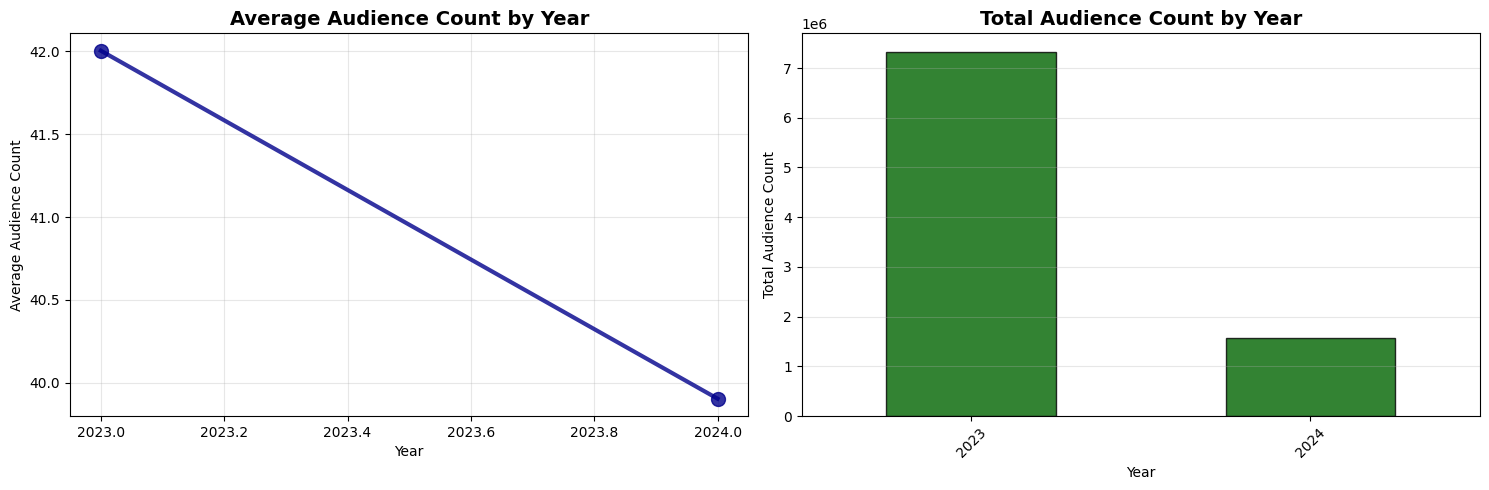

In [15]:
plt.figure(figsize=(15, 5))

booknow_visits['year'] = booknow_visits['show_date'].dt.year

plt.subplot(1, 2, 1)
yearly_avg = booknow_visits.groupby('year')['audience_count'].mean()
yearly_avg.plot(kind='line', marker='o', linewidth=3, markersize=10, 
                color='darkblue', alpha=0.8)
plt.title('Average Audience Count by Year', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Average Audience Count')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
yearly_total = booknow_visits.groupby('year')['audience_count'].sum()
yearly_total.plot(kind='bar', color='darkgreen', edgecolor='black', alpha=0.8)
plt.title('Total Audience Count by Year', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total Audience Count')
plt.xticks(rotation=45)
plt.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
plt.show()

**Insights:**
- Year-over-year trends show growth or decline in cinema attendance over time
- Long-term patterns help identify industry trends and external factors
- Both average and total metrics provide different perspectives on demand changes
- Historical trends inform future predictions and business planning

### 11. Booking Source Analysis


, we are integrating data from two distinct sources:
1.  **CinePOS:** Likely the internal Point-of-Sale system of the cinema chains (captures all transactions/walk-ins).
2.  **BookNow:** The specific online booking platform we are analyzing (captures only app/web users).

This visualization compares the **scale** of these two ecosystems to understand data coverage.




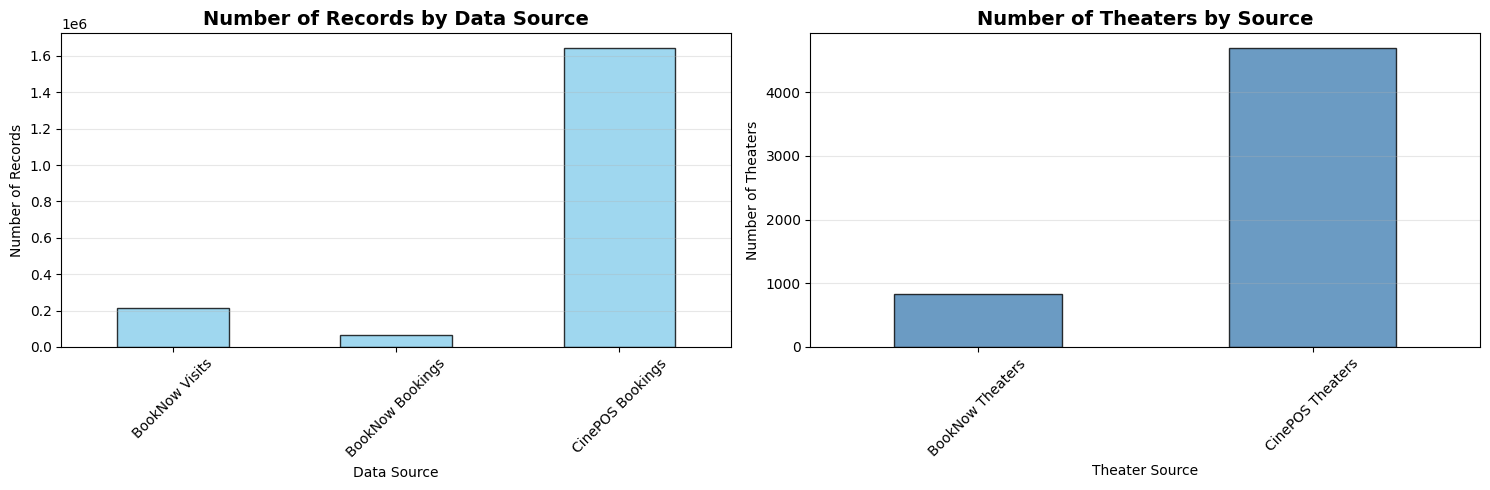

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Left subplot: Data Source Records
source_data = pd.DataFrame({
    'BookNow Visits': [len(booknow_visits)],
    'BookNow Bookings': [len(booknow_booking)],
    'CinePOS Bookings': [len(cinepos_booking)]
})
source_data.T.plot(kind='bar', color=['skyblue', 'lightcoral', 'lightgreen'], 
                   edgecolor='black', alpha=0.8, legend=False, ax=ax1)
ax1.set_title('Number of Records by Data Source', fontsize=14, fontweight='bold')
ax1.set_xlabel('Data Source')
ax1.set_ylabel('Number of Records')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(alpha=0.3, axis='y')

# Right subplot: Theater Counts
theater_counts = pd.DataFrame({
    'BookNow Theaters': [len(booknow_theaters)],
    'CinePOS Theaters': [len(cinepos_theaters)]
})
theater_counts.T.plot(kind='bar', color=['steelblue', 'indianred'], 
                      edgecolor='black', alpha=0.8, legend=False, ax=ax2)
ax2.set_title('Number of Theaters by Source', fontsize=14, fontweight='bold')
ax2.set_xlabel('Theater Source')
ax2.set_ylabel('Number of Theaters')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

**Insights:**
* **The Scale Discrepancy:** The *CinePOS* dataset (Right Bar, Light Blue) is massively larger than the *BookNow* dataset.
    * **Records:** CinePOS contains over **1.6 million** booking records, whereas BookNow has fewer than 200k.
    * **Inventory:** CinePOS tracks over **4,500 theaters**, while BookNow only operates in (or maps to) roughly **800 theaters**.
* **The "subset" Relationship:** This confirms that BookNow is likely a **subset** of the total market. We are effectively trying to predict the behavior of a specific user segment (online bookers) within a much larger universe of cinema-goers.
* **Integration Challenge:** Since CinePOS has thousands of theaters that do not exist in BookNow, a simple "Inner Join" would result in massive data loss. We must be careful to only use CinePOS features for theaters that actually exist in the BookNow target set.

### 12. Weekend vs Weekday Comparison

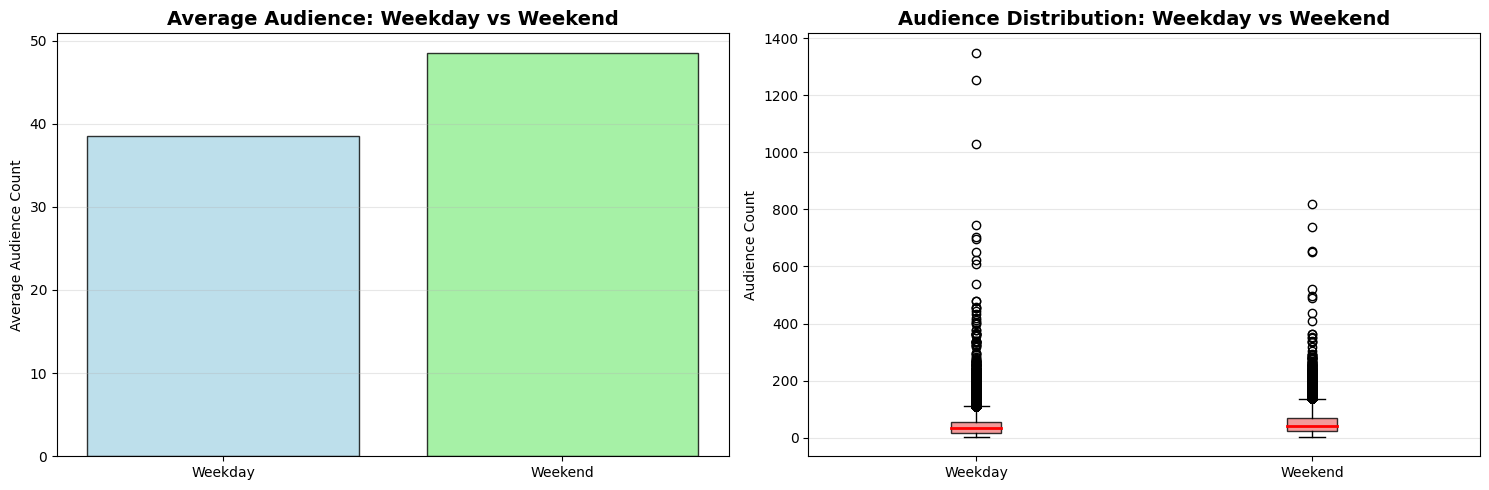

In [17]:
plt.figure(figsize=(15, 5))

booknow_visits['dayofweek'] = booknow_visits['show_date'].dt.dayofweek
booknow_visits['is_weekend'] = booknow_visits['dayofweek'].isin([5, 6]).astype(int)

plt.subplot(1, 2, 1)
weekend_comparison = booknow_visits.groupby('is_weekend')['audience_count'].mean()
weekend_labels = ['Weekday', 'Weekend']
plt.bar(weekend_labels, weekend_comparison.values, color=['lightblue', 'lightgreen'], 
        edgecolor='black', alpha=0.8)
plt.title('Average Audience: Weekday vs Weekend', fontsize=14, fontweight='bold')
plt.ylabel('Average Audience Count')
plt.grid(alpha=0.3, axis='y')

plt.subplot(1, 2, 2)
weekend_box_data = [booknow_visits[booknow_visits['is_weekend']==0]['audience_count'],
                     booknow_visits[booknow_visits['is_weekend']==1]['audience_count']]
plt.boxplot(weekend_box_data, labels=weekend_labels, patch_artist=True,
            boxprops=dict(facecolor='lightcoral', alpha=0.8),
            medianprops=dict(color='red', linewidth=2))
plt.title('Audience Distribution: Weekday vs Weekend', fontsize=14, fontweight='bold')
plt.ylabel('Audience Count')
plt.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

**Insights:**
- Clear distinction between weekday and weekend audience patterns
- Weekends typically attract higher cinema attendance than weekdays
- Distribution shows different variance patterns between weekdays and weekends
- Binary weekend feature is valuable for capturing weekly cyclical patterns

## 5. Data Preprocessing


In this step, we address the missing values identified during the EDA phase. Specifically, we focus on the `latitude` and `longitude` columns in the `cinepos_theaters` dataset.

*  Median Imputation.
*  We replace `NaN` values with the median of the respective column.
*  We use the **median** instead of the mean because geospatial coordinates can be skewed by outliers The median provides a more robust central tendency for location data, ensuring the imputed coordinates land within a realistic central region of our theater network.

In [18]:
# Handle missing geospatial data
print("Preprocessing  1: Handle Missing Values")
print("="*50)

# Impute missing coordinates with median values
cinepos_theaters['latitude'].fillna(cinepos_theaters['latitude'].median(), inplace=True)
cinepos_theaters['longitude'].fillna(cinepos_theaters['longitude'].median(), inplace=True)

print(f" Filled {cinepos_theaters['latitude'].isna().sum()} missing latitude values")
print(f" Filled {cinepos_theaters['longitude'].isna().sum()} missing longitude values")

Preprocessing  1: Handle Missing Values
 Filled 0 missing latitude values
 Filled 0 missing longitude values


In [19]:
# Merge theater information with visits data
print("\nPreprocessing : Data Integration")
print("="*50)

booknow_visits = booknow_visits.merge(
    booknow_theaters[['book_theater_id', 'theater_type', 'theater_area']],
    on='book_theater_id',
    how='left'
)

print(f" Integrated theater characteristics")
print(f"  Final shape: {booknow_visits.shape}")


Preprocessing : Data Integration
 Integrated theater characteristics
  Final shape: (214046, 10)


In [20]:
# Add temporal information from date_info
booknow_visits = booknow_visits.merge(date_info, on='show_date', how='left')

print(f" Added temporal features from date_info")
print(f"  Columns added: {[col for col in date_info.columns if col != 'show_date']}")

 Added temporal features from date_info
  Columns added: ['day_of_week']


In [21]:
# Encode categorical variables
print("\nPreprocessing : Categorical Encoding")
print("="*50)

label_encoder_type = LabelEncoder()
label_encoder_area = LabelEncoder()

booknow_visits['theater_type_encoded'] = label_encoder_type.fit_transform(booknow_visits['theater_type'])
booknow_visits['theater_area_encoded'] = label_encoder_area.fit_transform(booknow_visits['theater_area'])

print(f" Encoded theater_type: {booknow_visits['theater_type'].nunique()} categories")
print(f" Encoded theater_area: {booknow_visits['theater_area'].nunique()} categories")


Preprocessing : Categorical Encoding
 Encoded theater_type: 4 categories
 Encoded theater_area: 71 categories


##  6. Feature Engineering

In [22]:
# Sort data for temporal features
booknow_visits = booknow_visits.sort_values(['book_theater_id', 'show_date']).reset_index(drop=True)

print("Feature Engineering - Data Preparation")
print("="*50)
print(f" Data sorted by theater and date")
print(f"  Total records: {len(booknow_visits)}")

Feature Engineering - Data Preparation
 Data sorted by theater and date
  Total records: 214046


In [23]:
# Create additional temporal features if not present in date_info
print("\nCreating Temporal Features...")
print("="*50)

# Check and add year if not present
if 'year' not in booknow_visits.columns:
    booknow_visits['year'] = booknow_visits['show_date'].dt.year
    print(" Created 'year' feature")

# Check and add month if not present
if 'month' not in booknow_visits.columns:
    booknow_visits['month'] = booknow_visits['show_date'].dt.month
    print(" Created 'month' feature")

# Check and add day if not present
if 'day' not in booknow_visits.columns:
    booknow_visits['day'] = booknow_visits['show_date'].dt.day
    print(" Created 'day' feature")

# Day of week numeric
booknow_visits['day_of_week_numeric'] = booknow_visits['show_date'].dt.dayofweek
print(" Created 'day_of_week_numeric' feature")

# Weekend indicator
booknow_visits['is_weekend'] = booknow_visits['day_of_week_numeric'].isin([5, 6]).astype(int)
print(" Created 'is_weekend' feature")

# Check and add quarter if not present
if 'quarter' not in booknow_visits.columns:
    booknow_visits['quarter'] = booknow_visits['show_date'].dt.quarter
    print(" Created 'quarter' feature")

# Day of year
booknow_visits['day_of_year'] = booknow_visits['show_date'].dt.dayofyear
print(" Created 'day_of_year' feature")

print(f"\nTotal temporal features: 7")


Creating Temporal Features...
 Created 'day' feature
 Created 'day_of_week_numeric' feature
 Created 'is_weekend' feature
 Created 'day_of_year' feature

Total temporal features: 7


In [24]:
# Cyclical encoding for periodic features
print("\nCreating Cyclical Encodings...")
print("="*50)

booknow_visits['month_sin'] = np.sin(2 * np.pi * booknow_visits['month'] / 12)
booknow_visits['month_cos'] = np.cos(2 * np.pi * booknow_visits['month'] / 12)
booknow_visits['weekday_sin'] = np.sin(2 * np.pi * booknow_visits['day_of_week_numeric'] / 7)
booknow_visits['weekday_cos'] = np.cos(2 * np.pi * booknow_visits['day_of_week_numeric'] / 7)

print(" Created cyclical encodings for month and weekday")
print("  Features: month_sin, month_cos, weekday_sin, weekday_cos")


Creating Cyclical Encodings...
 Created cyclical encodings for month and weekday
  Features: month_sin, month_cos, weekday_sin, weekday_cos


In [25]:
# Create lag features for historical patterns
print("\nCreating Lag Features...")
print("="*50)

lag_periods = [1, 7, 14, 30]
for lag in lag_periods:
    col_name = f'audience_lag_{lag}d'
    booknow_visits[col_name] = booknow_visits.groupby('book_theater_id')['audience_count'].shift(lag)
    print(f" Created {col_name}")


Creating Lag Features...
 Created audience_lag_1d
 Created audience_lag_7d
 Created audience_lag_14d
 Created audience_lag_30d


In [26]:
# Create rolling window statistics
print("\nCreating Rolling Window Features...")
print("="*50)

window_sizes = [7, 14, 30]
for window in window_sizes:
    # Rolling mean
    mean_col = f'audience_mean_{window}d'
    booknow_visits[mean_col] = booknow_visits.groupby('book_theater_id')['audience_count'].transform(
        lambda x: x.rolling(window, min_periods=1).mean()
    )
    
    # Rolling standard deviation
    std_col = f'audience_std_{window}d'
    booknow_visits[std_col] = booknow_visits.groupby('book_theater_id')['audience_count'].transform(
        lambda x: x.rolling(window, min_periods=1).std()
    )
    
    print(f" Created {mean_col} and {std_col}")


Creating Rolling Window Features...
 Created audience_mean_7d and audience_std_7d
 Created audience_mean_14d and audience_std_14d
 Created audience_mean_30d and audience_std_30d


In [27]:
# Create theater-level aggregate statistics
print("\nCreating Theater-Level Statistics...")
print("="*50)

theater_aggregates = booknow_visits.groupby('book_theater_id')['audience_count'].agg([
    'mean', 'median', 'std', 'min', 'max'
]).reset_index()
theater_aggregates.columns = ['book_theater_id', 'theater_mean', 'theater_median', 
                               'theater_std', 'theater_min', 'theater_max']

booknow_visits = booknow_visits.merge(theater_aggregates, on='book_theater_id', how='left')

print(" Added theater-level statistics")
print("  Features: mean, median, std, min, max")


Creating Theater-Level Statistics...
 Added theater-level statistics
  Features: mean, median, std, min, max


In [28]:
# Create day-of-week specific statistics per theater
print("\nCreating Day-of-Week Statistics...")
print("="*50)

dow_aggregates = booknow_visits.groupby(['book_theater_id', 'day_of_week'])['audience_count'].agg([
    'mean', 'median', 'count'
]).reset_index()
dow_aggregates.columns = ['book_theater_id', 'day_of_week', 'dow_mean', 'dow_median', 'dow_count']

booknow_visits = booknow_visits.merge(dow_aggregates, on=['book_theater_id', 'day_of_week'], how='left')

print(" Added day-of-week specific statistics")
print("  Features: dow_mean, dow_median, dow_count")


Creating Day-of-Week Statistics...
 Added day-of-week specific statistics
  Features: dow_mean, dow_median, dow_count


In [29]:
# Handle any remaining missing values in engineered features
booknow_visits.fillna(0, inplace=True)

print("\nFeature Engineering Complete")
print("="*50)
print(f"Total features: {booknow_visits.shape[1]}")
print(f" Missing values: {booknow_visits.isnull().sum().sum()}")


Feature Engineering Complete
Total features: 38
 Missing values: 0


##  7. Model Training and Evaluation

In [30]:
# Define feature columns for modeling
feature_columns = [
    'year', 'month', 'day', 'day_of_week_numeric', 'is_weekend', 'quarter',
    'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos',
    'theater_type_encoded', 'theater_area_encoded',
    'audience_lag_1d', 'audience_lag_7d', 'audience_lag_14d', 'audience_lag_30d',
    'audience_mean_7d', 'audience_std_7d',
    'audience_mean_14d', 'audience_std_14d',
    'audience_mean_30d', 'audience_std_30d',
    'theater_mean', 'theater_median', 'theater_std',
    'dow_mean', 'dow_median'
]

print("Model Training Preparation")
print("="*50)
print(f" Selected {len(feature_columns)} features for modeling")

Model Training Preparation
 Selected 27 features for modeling


In [31]:
# Filter data with sufficient historical information
training_data = booknow_visits[booknow_visits['audience_lag_7d'] > 0].copy()

X = training_data[feature_columns]
y = training_data['audience_count']

print(f"\nData for modeling:")
print(f"  Total samples: {len(X)}")
print(f"  Features: {X.shape[1]}")
print(f"  Target range: [{y.min()}, {y.max()}]")


Data for modeling:
  Total samples: 208275
  Features: 27
  Target range: [2, 1350]


In [32]:
# Time-series train-test split (80-20)
split_point = int(len(X) * 0.8)
X_train, X_validation = X[:split_point], X[split_point:]
y_train, y_validation = y[:split_point], y[split_point:]

print("\nTrain-Validation Split:")
print(f"  Training samples: {len(X_train)}")
print(f"  Validation samples: {len(X_validation)}")


Train-Validation Split:
  Training samples: 166620
  Validation samples: 41655


In [33]:
# Define and train multiple models
model_definitions = {
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=8, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, max_depth=8, learning_rate=0.1, random_state=42, n_jobs=-1),
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, max_depth=8, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1)
}

print("\nTraining Multiple Models...")
print("="*50)


Training Multiple Models...


In [34]:
# Train and evaluate each model
model_performance = {}

for model_name, model_instance in model_definitions.items():
    print(f"\n[{model_name}]")
    
    # Train the model
    model_instance.fit(X_train, y_train)
    
    # Generate predictions
    train_predictions = model_instance.predict(X_train)
    val_predictions = model_instance.predict(X_validation)
    
    # Calculate metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
    val_rmse = np.sqrt(mean_squared_error(y_validation, val_predictions))
    train_mae = mean_absolute_error(y_train, train_predictions)
    val_mae = mean_absolute_error(y_validation, val_predictions)
    train_r2 = r2_score(y_train, train_predictions)
    val_r2 = r2_score(y_validation, val_predictions)
    
    # Store results
    model_performance[model_name] = {
        'train_rmse': train_rmse,
        'val_rmse': val_rmse,
        'train_mae': train_mae,
        'val_mae': val_mae,
        'train_r2': train_r2,
        'val_r2': val_r2,
        'model': model_instance
    }
    
    print(f"  Train RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f}")
    print(f"  Train MAE:  {train_mae:.4f} | Val MAE:  {val_mae:.4f}")
    print(f"  Train R²:   {train_r2:.4f} | Val R²:   {val_r2:.4f}")


[Random Forest]
  Train RMSE: 13.1329 | Val RMSE: 16.8249
  Train MAE:  9.3921 | Val MAE:  11.3054
  Train R²:   0.8443 | Val R²:   0.6999

[Gradient Boosting]
  Train RMSE: 14.7128 | Val RMSE: 16.3907
  Train MAE:  10.7034 | Val MAE:  11.0445
  Train R²:   0.8046 | Val R²:   0.7152

[XGBoost]
  Train RMSE: 14.8581 | Val RMSE: 16.3650
  Train MAE:  10.7056 | Val MAE:  11.0202
  Train R²:   0.8007 | Val R²:   0.7161

[LightGBM]
  Train RMSE: 17.4370 | Val RMSE: 16.6029
  Train MAE:  11.9726 | Val MAE:  11.2777
  Train R²:   0.7256 | Val R²:   0.7077


In [35]:
# Display model comparison table
print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)

comparison_table = pd.DataFrame(model_performance).T[['train_rmse', 'val_rmse', 'train_mae', 'val_mae', 'train_r2', 'val_r2']]
print(comparison_table.to_string())

# Identify best model
best_model_name = min(model_performance.items(), key=lambda x: x[1]['val_rmse'])[0]
best_model_instance = model_performance[best_model_name]['model']

print(f"\n🏆 Best Model: {best_model_name}")
print(f"   Validation RMSE: {model_performance[best_model_name]['val_rmse']:.4f}")


MODEL COMPARISON
                  train_rmse   val_rmse  train_mae    val_mae  train_r2    val_r2
Random Forest      13.132862  16.824898   9.392108  11.305378  0.844322  0.699879
Gradient Boosting  14.712753  16.390681   10.70335   11.04448  0.804613   0.71517
XGBoost            14.858103  16.365044  10.705605  11.020168  0.800733   0.71606
LightGBM           17.436955  16.602923  11.972599   11.27774  0.725558  0.707745

🏆 Best Model: XGBoost
   Validation RMSE: 16.3650


## 8. Hyperparameter Tuning

In [36]:
# Hyperparameter tuning for the best performing model
print("\nHyperparameter Tuning")
print("="*80)
print(f"Tuning best model: {best_model_name}\n")

# Define parameter search space based on best model type
if 'XGBoost' in best_model_name:
    param_space = {
        'n_estimators': [100, 150, 200, 250],
        'max_depth': [6, 8, 10, 12],
        'learning_rate': [0.05, 0.08, 0.1, 0.15],
        'subsample': [0.8, 0.9, 1.0],
        'colsample_bytree': [0.8, 0.9, 1.0]
    }
elif 'LightGBM' in best_model_name:
    param_space = {
        'n_estimators': [100, 150, 200, 250],
        'max_depth': [6, 8, 10, 12],
        'learning_rate': [0.05, 0.08, 0.1, 0.15],
        'subsample': [0.8, 0.9, 1.0],
        'colsample_bytree': [0.8, 0.9, 1.0]
    }
elif 'Random Forest' in best_model_name:
    param_space = {
        'n_estimators': [100, 150, 200],
        'max_depth': [10, 15, 20, 25],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
elif 'Gradient Boosting' in best_model_name:
    param_space = {
        'n_estimators': [100, 150, 200],
        'max_depth': [6, 8, 10],
        'learning_rate': [0.05, 0.1, 0.15],
        'subsample': [0.8, 0.9, 1.0]
    }
else:
    param_space = {}

print(f"Parameter search space:")
for param, values in param_space.items():
    print(f"  {param}: {values}")


Hyperparameter Tuning
Tuning best model: XGBoost

Parameter search space:
  n_estimators: [100, 150, 200, 250]
  max_depth: [6, 8, 10, 12]
  learning_rate: [0.05, 0.08, 0.1, 0.15]
  subsample: [0.8, 0.9, 1.0]
  colsample_bytree: [0.8, 0.9, 1.0]


In [37]:
# Perform RandomizedSearchCV for efficient hyperparameter tuning
if param_space:
    print("\nPerforming randomized search (20 iterations, 3-fold CV)...")
    
    random_search = RandomizedSearchCV(
        estimator=best_model_instance,
        param_distributions=param_space,
        n_iter=20,
        cv=3,
        scoring='neg_mean_squared_error',
        random_state=42,
        n_jobs=-1,
        verbose=1
    )
    
    # Fit the random search
    random_search.fit(X_train, y_train)
    
    print("\n Hyperparameter tuning complete")
    print(f"\nBest parameters found:")
    for param, value in random_search.best_params_.items():
        print(f"  {param}: {value}")
    
    # Get the tuned model
    tuned_model = random_search.best_estimator_
    
else:
    print("\n No parameter space defined for this model type")
    tuned_model = best_model_instance


Performing randomized search (20 iterations, 3-fold CV)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

 Hyperparameter tuning complete

Best parameters found:
  subsample: 1.0
  n_estimators: 150
  max_depth: 10
  learning_rate: 0.05
  colsample_bytree: 0.8


In [38]:
# Evaluate tuned model performance
print("\nEvaluating Tuned Model Performance:")
print("="*50)

# Predictions with tuned model
tuned_train_pred = tuned_model.predict(X_train)
tuned_val_pred = tuned_model.predict(X_validation)

# Calculate metrics
tuned_train_rmse = np.sqrt(mean_squared_error(y_train, tuned_train_pred))
tuned_val_rmse = np.sqrt(mean_squared_error(y_validation, tuned_val_pred))
tuned_train_mae = mean_absolute_error(y_train, tuned_train_pred)
tuned_val_mae = mean_absolute_error(y_validation, tuned_val_pred)
tuned_train_r2 = r2_score(y_train, tuned_train_pred)
tuned_val_r2 = r2_score(y_validation, tuned_val_pred)

print(f"\nOriginal Model Performance:")
print(f"  Train RMSE: {model_performance[best_model_name]['train_rmse']:.4f} | Val RMSE: {model_performance[best_model_name]['val_rmse']:.4f}")
print(f"  Train R²:   {model_performance[best_model_name]['train_r2']:.4f} | Val R²:   {model_performance[best_model_name]['val_r2']:.4f}")

print(f"\nTuned Model Performance:")
print(f"  Train RMSE: {tuned_train_rmse:.4f} | Val RMSE: {tuned_val_rmse:.4f}")
print(f"  Train MAE:  {tuned_train_mae:.4f} | Val MAE:  {tuned_val_mae:.4f}")
print(f"  Train R²:   {tuned_train_r2:.4f} | Val R²:   {tuned_val_r2:.4f}")

# Compare improvement
rmse_improvement = model_performance[best_model_name]['val_rmse'] - tuned_val_rmse
r2_improvement = tuned_val_r2 - model_performance[best_model_name]['val_r2']

print(f"\nImprovement:")
print(f"  RMSE reduction: {rmse_improvement:.4f} ({rmse_improvement/model_performance[best_model_name]['val_rmse']*100:.2f}%)")
print(f"  R² increase: {r2_improvement:.4f}")

# Use tuned model if it performs better
if tuned_val_rmse < model_performance[best_model_name]['val_rmse']:
    best_model_instance = tuned_model
    print("\n Tuned model shows improvement - using tuned version for predictions")
else:
    print("\n Original model performs better - keeping original version")


Evaluating Tuned Model Performance:

Original Model Performance:
  Train RMSE: 14.8581 | Val RMSE: 16.3650
  Train R²:   0.8007 | Val R²:   0.7161

Tuned Model Performance:
  Train RMSE: 12.9023 | Val RMSE: 16.2442
  Train MAE:  9.5096 | Val MAE:  10.9823
  Train R²:   0.8497 | Val R²:   0.7202

Improvement:
  RMSE reduction: 0.1209 (0.74%)
  R² increase: 0.0042

 Tuned model shows improvement - using tuned version for predictions


## 9: Prediction Implementation

In [39]:
# Define weighted ensemble prediction function
def generate_weighted_predictions(test_data, historical_data):
    """
     predictions using confidence-weighted ensemble approach:
    - Historical day-of-week patterns (weighted by data availability)
    - Recent trends (7-day and 30-day rolling averages)
    - Fallbacks: theater type average, theater area average, global day-of-week average
    """
    predictions_list = []
    
    for idx, record in test_data.iterrows():
        theater = record['book_theater_id']
        target_date = record['show_date']
        day_name = record['day_of_week']
        
        # Extract historical data for specific theater
        theater_data = historical_data[historical_data['book_theater_id'] == theater].copy()
        
        prediction_values = []
        prediction_weights = []
        
        # Strategy 1: Day-of-week historical pattern (confidence-weighted)
        dow_records = theater_data[theater_data['day_of_week'] == day_name]
        if len(dow_records) > 0:
            dow_avg = dow_records['audience_count'].mean()
            dow_med = dow_records['audience_count'].median()
            record_count = len(dow_records)
            
            # Assign weights based on data availability
            if record_count >= 5:
                prediction_values.append(dow_avg)
                prediction_weights.append(0.45)
            elif record_count >= 3:
                prediction_values.append((dow_avg + dow_med) / 2)
                prediction_weights.append(0.35)
            else:
                prediction_values.append(dow_med)
                prediction_weights.append(0.25)
        
        # Strategy 2: Recent trend analysis
        if len(theater_data) > 0:
            # 7-day recent trend
            recent_7 = theater_data.tail(7)['audience_count'].mean()
            prediction_values.append(recent_7)
            prediction_weights.append(0.30)
            
            # 30-day recent trend
            recent_30 = theater_data.tail(30)['audience_count'].mean()
            prediction_values.append(recent_30)
            prediction_weights.append(0.15)
            
            # Theater baseline
            theater_baseline = theater_data['audience_count'].median()
            prediction_values.append(theater_baseline)
            prediction_weights.append(0.10)
        
        # Fallback Strategy 1: Theater type average
        if len(prediction_values) == 0:
            theater_type = record['theater_type']
            type_records = historical_data[(historical_data['theater_type'] == theater_type) & 
                                          (historical_data['day_of_week'] == day_name)]
            if len(type_records) > 0:
                prediction_values.append(type_records['audience_count'].mean())
                prediction_weights.append(1.0)
        
        # Fallback Strategy 2: Theater area average
        if len(prediction_values) == 0:
            theater_area = record['theater_area']
            area_records = historical_data[(historical_data['theater_area'] == theater_area) & 
                                          (historical_data['day_of_week'] == day_name)]
            if len(area_records) > 0:
                prediction_values.append(area_records['audience_count'].mean())
                prediction_weights.append(1.0)
        
        # Fallback Strategy 3: Global day-of-week average
        if len(prediction_values) == 0:
            global_dow_avg = historical_data[historical_data['day_of_week'] == day_name]['audience_count'].mean()
            prediction_values.append(global_dow_avg if not np.isnan(global_dow_avg) else 50)
            prediction_weights.append(1.0)
        
        # Calculate weighted prediction
        weights_array = np.array(prediction_weights)
        weights_array = weights_array / weights_array.sum()
        final_prediction = np.sum(np.array(prediction_values) * weights_array)
        final_prediction = max(0, round(final_prediction))
        
        predictions_list.append(final_prediction)
    
    return predictions_list

print(" Prediction strategy function defined")

 Prediction strategy function defined


## 10. Prepare Test Data and Generate Predictions

In [40]:
# Parse test IDs from submission template
test_data = sample_submission.copy()
test_data['book_theater_id'] = test_data['ID'].str.rsplit('_', n=1).str[0]
test_data['show_date'] = pd.to_datetime(test_data['ID'].str.rsplit('_', n=1).str[1])

print("Test Data Preparation")
print("="*50)
print(f"Test samples: {len(test_data)}")

Test Data Preparation
Test samples: 38062


In [41]:
# Merge theater and temporal information
test_data = test_data.merge(
    booknow_theaters[['book_theater_id', 'theater_type', 'theater_area']],
    on='book_theater_id',
    how='left'
)

test_data = test_data.merge(date_info, on='show_date', how='left')

print(f" Merged theater and date information")
print(f"  Date range: {test_data['show_date'].min()} to {test_data['show_date'].max()}")
print(f"  Unique theaters: {test_data['book_theater_id'].nunique()}")

 Merged theater and date information
  Date range: 2024-03-01 00:00:00 to 2024-04-22 00:00:00
  Unique theaters: 827


In [42]:
# Generate predictions using weighted ensemble strategy
print("\nGenerating predictions...")
final_predictions = generate_weighted_predictions(test_data, booknow_visits)

print(f" Generated {len(final_predictions)} predictions")
print(f"\nPrediction Statistics:")
print(f"  Minimum: {np.min(final_predictions)}")
print(f"  Maximum: {np.max(final_predictions)}")
print(f"  Mean: {np.mean(final_predictions):.2f}")
print(f"  Median: {np.median(final_predictions):.2f}")


Generating predictions...
 Generated 38062 predictions

Prediction Statistics:
  Minimum: 2
  Maximum: 168
  Mean: 41.31
  Median: 37.00


## 11. Creating and Saving Submission File

In [43]:
# Create submission file
submission = pd.DataFrame({
    'ID': sample_submission['ID'],
    'audience_count': final_predictions
})

# Save to CSV
submission.to_csv('submission.csv', index=False)

print("Submission File Created")
print("="*50)
print(f" File saved as 'submission.csv'")
print(f" Total predictions: {len(submission)}")
print(f"\nSample predictions:")
print(submission.head(10).to_string(index=False))

Submission File Created
 File saved as 'submission.csv'
 Total predictions: 38062

Sample predictions:
                   ID  audience_count
book_00001_2024-03-01              41
book_00001_2024-03-02              52
book_00001_2024-03-03              49
book_00001_2024-03-04              31
book_00001_2024-03-06              39
book_00001_2024-03-07              43
book_00001_2024-03-08              41
book_00001_2024-03-09              52
book_00001_2024-03-10              49
book_00001_2024-03-11              31
